In [2]:
import numpy as np
import os
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
os.makedirs("../results", exist_ok=True)



# import the library u need

### Load the data

In [4]:
X_train = np.load("../processed/X_train_norm.npy")
X_val   = np.load("../processed/X_val_norm.npy")
X_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")



In [5]:
#Verification
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


In [6]:
# Model Evaluation
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

def evaluate_classification(y_true, y_pred, plot=False, title="Model Evaluation"):

    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    accuracy  = accuracy_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"{title}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 score : {f1:.4f}")

    if plot:
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(4,4))
        plt.imshow(cm, cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        for (i, j), v in np.ndenumerate(cm):
            plt.text(j, i, str(v), ha="center", va="center")

        plt.colorbar()
        plt.show()

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [7]:
# # class sklearn.linear_model.LogisticRegression(penalty='deprecated', *, 
# C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, 
# class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)

Logistic Regression
Accuracy : 0.9213
Precision: 0.9207
Recall   : 0.9203
F1 score : 0.9204


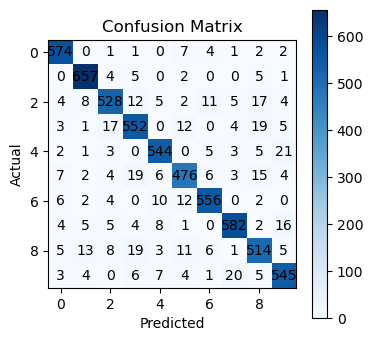

{'accuracy': 0.9213333333333333,
 'precision': 0.9206672218145965,
 'recall': 0.9202520830396314,
 'f1': 0.9203644799366202}

In [8]:
# logistic regression 
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=500, random_state=42)
baseline_model.fit(X_train, y_train)

y_val_pred = baseline_model.predict(X_val)

# Bewertung
evaluate_classification(y_val, y_val_pred, plot=True, title="Logistic Regression")



# ROC Curve


### Load the model results for comparison

In [10]:
### ../results/final_comparison.ipynb

In [11]:
# those are just exemples :)
# You can add additional dictionaries to results depending on your model’s outputs or training information.
c = 5
penalty = 1.3
results = {
    "model": "LG",
    "best_params": {"C": int(c), "penalty": penalty},
    "metrics": {
        "accuracy": 0.6,
        "precision": 0.57,
        "recall": 0.88,
        "f1": 0.8,
    },
    "scores": {
        "train_accuracy": 0.88,
        "val_accuracy": 0.84,
        "test_accuracy": 0.54,
    },
}
with open("../results/logisticReg.json", "w") as f:
    json.dump(results, f, indent=2)